# Visualizacion de Evaluaciones del Pipeline

Notebook para revisar resultados de `pilot`, `end-to-end` y, si existe, la barrida de `threshold`.

Uso recomendado:
- volver a ejecutar primero los scripts de evaluacion,
- actualizar las rutas en la celda de configuracion si hace falta,
- refrescar tablas y graficos antes de documentar resultados.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'logs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

pilot_dir = PROJECT_ROOT / 'logs' / 'pilot_eval'
end_to_end_dir = PROJECT_ROOT / 'logs' / 'end_to_end_eval'

# Ajusta estas rutas si guardas la barrida en otra carpeta.
pilot_sweep_dir = PROJECT_ROOT / 'logs' / 'pilot_threshold_sweep'
end_to_end_sweep_dir = PROJECT_ROOT / 'logs' / 'end_to_end_threshold_sweep'

def load_json(path: Path):
    if not path.exists():
        return None
    with path.open('r', encoding='utf-8') as fh:
        return json.load(fh)

def load_csv(path: Path):
    if not path.exists():
        return None
    return pd.read_csv(path)

pilot_summary = load_json(pilot_dir / 'summary.json')
pilot_predictions = load_csv(pilot_dir / 'predictions.csv')
pilot_failures = load_csv(pilot_dir / 'failures.csv')

e2e_summary = load_json(end_to_end_dir / 'summary.json')
e2e_predictions = load_csv(end_to_end_dir / 'predictions.csv')
e2e_failures = load_csv(end_to_end_dir / 'failures.csv')

pilot_sweep = load_csv(pilot_sweep_dir / 'threshold_sweep.csv')
e2e_sweep = load_csv(end_to_end_sweep_dir / 'threshold_sweep.csv')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('pilot_summary:', pilot_summary is not None)
print('e2e_summary:', e2e_summary is not None)
print('pilot_sweep:', pilot_sweep is not None)
print('e2e_sweep:', e2e_sweep is not None)


PROJECT_ROOT = <local project root>
pilot_summary: True
e2e_summary: True
pilot_sweep: True
e2e_sweep: True


## Comparacion de metricas principales

In [3]:
rows = []

if pilot_summary is not None:
    m = pilot_summary['metrics']
    rows.append({
        'evaluation': 'pilot',
        'cases': pilot_summary['total_rows'],
        'match_rate': m.get('pilot_match_rate', m.get('pilot_match_rate_all_rows', m.get('pilot_match_rate_found_images'))),
        'readable_rate': m.get('readable_rate'),
        'accuracy_when_readable': m.get('accuracy_when_readable'),
        'auto_validation_rate': m.get('auto_validation_rate'),
        'auto_validation_precision': m.get('auto_validation_precision'),
        'review_rate': m.get('review_rate'),
        'no_detection_rate': m.get('no_detection_rate'),
        'latency_p95_ms': pilot_summary['latency_ms']['total']['p95'],
    })

if e2e_summary is not None:
    m = e2e_summary['metrics']
    rows.append({
        'evaluation': 'end_to_end_test',
        'cases': e2e_summary['total_rows'],
        'match_rate': m.get('end_to_end_accuracy'),
        'readable_rate': m.get('readable_rate'),
        'accuracy_when_readable': m.get('accuracy_when_readable'),
        'auto_validation_rate': m.get('auto_validation_rate'),
        'auto_validation_precision': m.get('auto_validation_precision'),
        'review_rate': m.get('review_rate'),
        'no_detection_rate': m.get('no_detection_rate'),
        'latency_p95_ms': e2e_summary['latency_ms']['total']['p95'],
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)


,evaluation,cases,match_rate,readable_rate,accuracy_when_readable,auto_validation_rate,auto_validation_precision,review_rate,no_detection_rate,latency_p95_ms
0,pilot,300,0.8267,0.9267,0.8921,0.8333,0.9040,0.1000,0.0667,1508.9000
1,end_to_end_test,120,0.9583,1.0000,0.9583,0.9333,0.9643,0.0667,0.0000,596.2000


- **End-to-end (test controlado, 120 imagenes):** 95.83% de exactitud, 100% de tasa de lectura y 0% de no-deteccion. El pipeline resuelve todos los casos y solo falla en 5 lecturas.
- **Piloto (campo, 300 imagenes):** 82.67% de coincidencia, 92.67% de tasa de lectura y 6.67% de no-deteccion. La brecha respecto al test controlado refleja la variabilidad de las condiciones operativas: imagenes sin medidor, medidores sucios, fotos inclinadas.
- La precision de auto-validacion baja de 96.43% (test) a 90.40% (piloto), lo que indica que la confianza del modelo no discrimina errores con la misma eficacia sobre datos de campo.

## Tradeoff de umbral de validacion

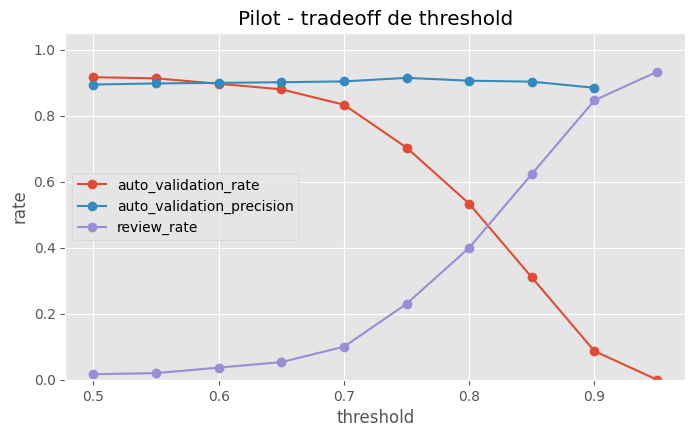

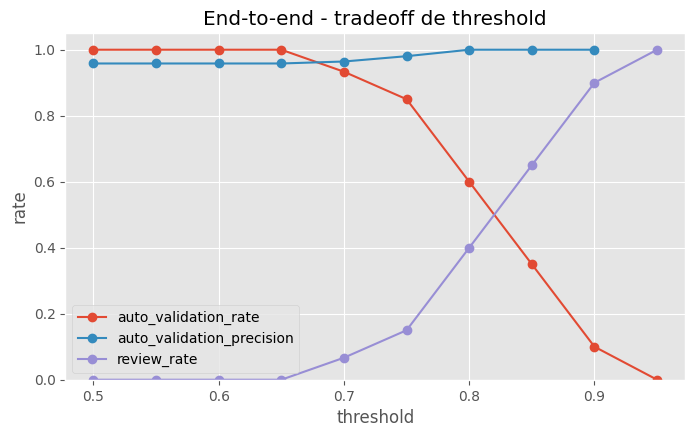

In [4]:
def plot_threshold_sweep(df: pd.DataFrame, title: str):
    if df is None or df.empty:
        print(f'No threshold sweep available for {title}.')
        return

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(df['threshold'], df['auto_validation_rate'], marker='o', label='auto_validation_rate')
    ax.plot(df['threshold'], df['auto_validation_precision'], marker='o', label='auto_validation_precision')
    ax.plot(df['threshold'], df['review_rate'], marker='o', label='review_rate')
    ax.set_title(title)
    ax.set_xlabel('threshold')
    ax.set_ylabel('rate')
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.show()

plot_threshold_sweep(pilot_sweep, 'Pilot - tradeoff de threshold')
plot_threshold_sweep(e2e_sweep, 'End-to-end - tradeoff de threshold')


Cada grafico muestra tres curvas al variar el umbral de `global_confidence`:

- **auto_validation_rate** (roja): proporcion de casos que el sistema resuelve sin intervencion humana. Baja al subir el umbral.
- **auto_validation_precision** (azul): de los casos auto-validados, que proporcion fue correcta.
- **review_rate** (morada): proporcion de casos enviados a revision humana.

**Hallazgo clave en el piloto:** la precision se mantiene plana (~90%) entre umbrales de 0.50 a 0.85. Subir el threshold no mejora la calidad de las decisiones automaticas, solo reduce la cobertura. Los errores no se concentran en las confianzas bajas — hay predicciones incorrectas con confianza alta. En datos operativos, la `global_confidence` no es un buen discriminador de errores.

**Contraste con el test controlado:** a threshold 0.80 la precision llega a 100% (los 4 errores auto-validados tenian confianza entre 0.70 y 0.79). En el test, la confianza si permite separar aciertos de errores.

**Punto de operacion (0.70):** 83% de autonomia en el piloto y 93% en test, con precision de 90% y 96% respectivamente.

## Distribucion de status y outcome

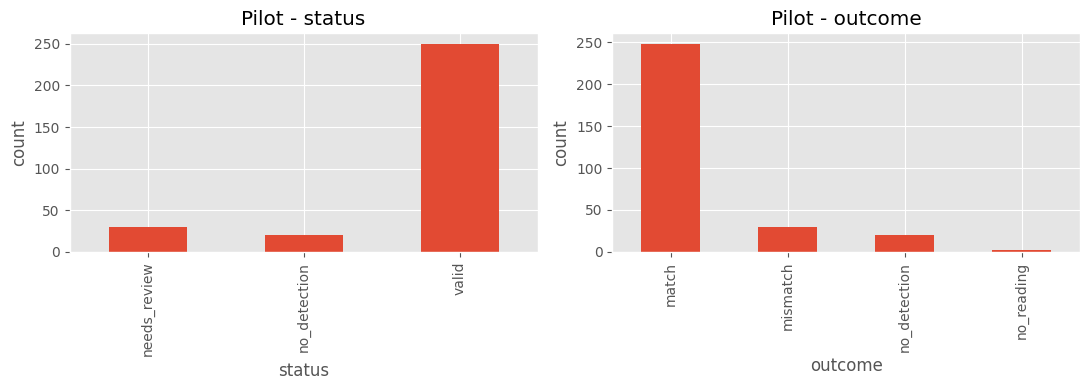

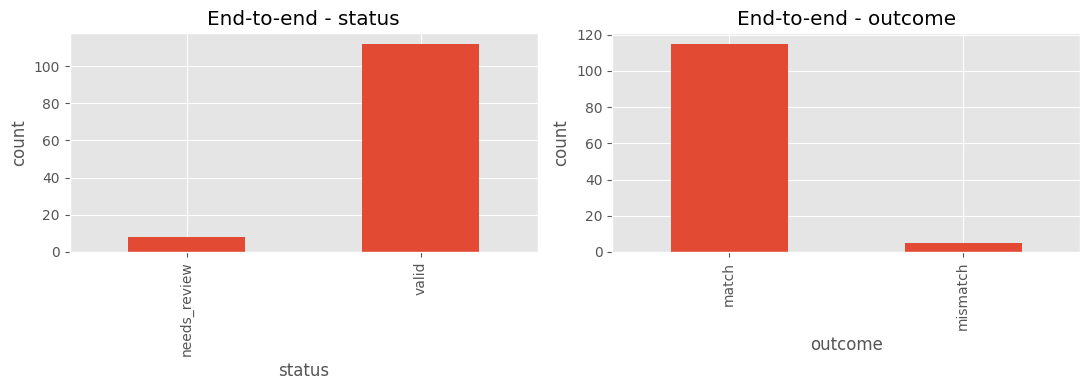

In [5]:
def plot_status_and_outcome(predictions: pd.DataFrame, title_prefix: str):
    if predictions is None or predictions.empty:
        print(f'No predictions available for {title_prefix}.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    predictions['status'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title=f'{title_prefix} - status')
    predictions['outcome'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title=f'{title_prefix} - outcome')
    axes[0].set_ylabel('count')
    axes[1].set_ylabel('count')
    plt.tight_layout()
    plt.show()

plot_status_and_outcome(pilot_predictions, 'Pilot')
plot_status_and_outcome(e2e_predictions, 'End-to-end')


- **Piloto:** 250 `valid`, 30 `needs_review`, 20 `no_detection`. En outcome: 248 coincidencias, 30 lecturas incorrectas, 20 sin deteccion y 2 sin lectura. Los 20 `no_detection` incluyen 14 imagenes que no contienen un medidor procesable (fachadas, tapas cerradas, medidores de reloj), por lo que solo 6 son fallos reales del detector.
- **End-to-end:** 112 `valid`, 8 `needs_review`, 0 `no_detection`. Los 5 errores se dividen en 3 por omision de digitos, 1 por orientacion incorrecta y 1 por digitos espurios.

## Desempeño por subgrupos (end-to-end)

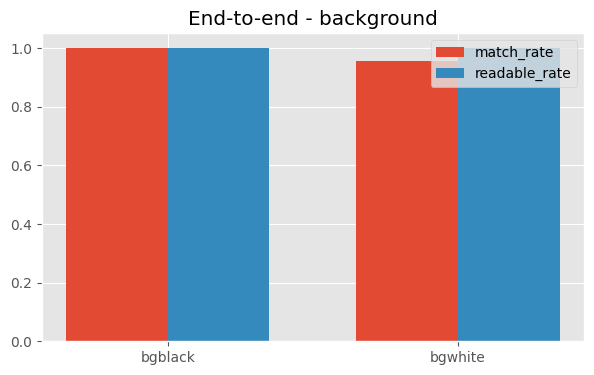

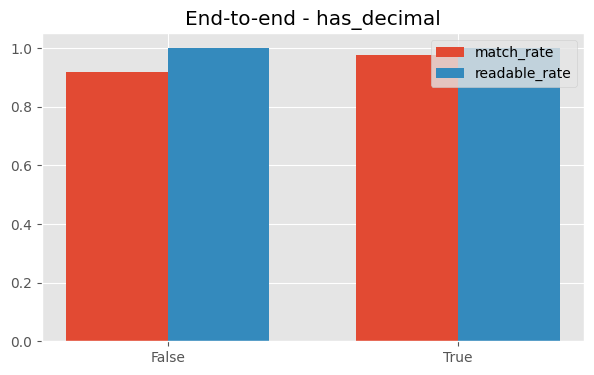

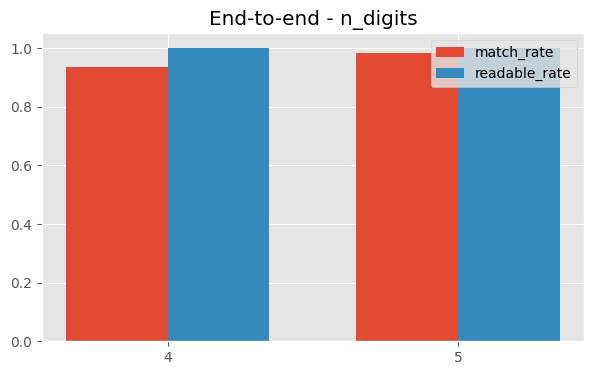

In [6]:
def subgroup_to_df(summary: dict, subgroup_name: str) -> pd.DataFrame:
    rows = []
    subgroup = summary['subgroups'].get(subgroup_name, {})
    for key, values in subgroup.items():
        rows.append({'group': key, **values})
    return pd.DataFrame(rows)

def plot_subgroup(summary: dict, subgroup_name: str, title: str):
    if summary is None or subgroup_name not in summary.get('subgroups', {}):
        print(f'Subgroup {subgroup_name} not available for {title}.')
        return

    df = subgroup_to_df(summary, subgroup_name)
    fig, ax = plt.subplots(figsize=(7, 4))
    width = 0.35
    x = range(len(df))
    ax.bar([i - width / 2 for i in x], df['match_rate'], width=width, label='match_rate')
    ax.bar([i + width / 2 for i in x], df['readable_rate'], width=width, label='readable_rate')
    ax.set_xticks(list(x))
    ax.set_xticklabels(df['group'])
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_subgroup(e2e_summary, 'background', 'End-to-end - background')
plot_subgroup(e2e_summary, 'has_decimal', 'End-to-end - has_decimal')
plot_subgroup(e2e_summary, 'n_digits', 'End-to-end - n_digits')


- **Background:** los 5 medidores con fondo negro alcanzan 100% de coincidencia; los 115 con fondo blanco, 95.65%. La muestra de fondo negro es muy pequena para sacar conclusiones, pero no se observan fallos en ese subgrupo.
- **Decimales:** medidores con decimales (84) alcanzan 97.62%, mientras que los de solo enteros (36) quedan en 91.67%. Esta brecha es consistente con el sesgo de posicion identificado en el analisis de explicabilidad.
- **Longitud de lectura:** medidores de 5 digitos (57) alcanzan 98.25%, superior a los de 4 digitos (63) con 93.65%. Esto sugiere que las lecturas mas largas, al tener mas caracteres visibles, ofrecen mas evidencia al OCR.

## Detalle de fallos

In [7]:
def show_failures(df: pd.DataFrame, columns: list[str], title: str, n: int = 10):
    if df is None or df.empty:
        print(f'No failures available for {title}.')
        return
    print(title)
    display(df[columns].head(n))

pilot_columns = ['serial', 'expected_raw', 'reading', 'predicted_norm', 'status', 'outcome', 'global_confidence', 'warnings']
e2e_columns = ['image', 'expected_raw', 'reading', 'predicted_norm', 'status', 'outcome', 'global_confidence', 'warnings']

show_failures(pilot_failures, pilot_columns, 'Pilot - primeros fallos')
show_failures(e2e_failures, e2e_columns, 'End-to-end - primeros fallos')


Pilot - primeros fallos


,serial,expected_raw,reading,predicted_norm,status,outcome,global_confidence,warnings
0,ANON001,140,NaN,NaN,no_detection,no_detection,0.0000,NaN
1,ANON002,11740,0.0000,0.0000,valid,mismatch,0.8664,"Orientation ambiguous (method=dual_ocr, delta=..."
2,ANON003,7295,729.0000,729.0000,valid,mismatch,0.8001,NaN
3,ANON004,1,0.0000,0.0000,valid,mismatch,0.7107,NaN
4,ANON005,3723,723.0000,723.0000,valid,mismatch,0.7621,NaN
5,ANON006,3900,390.0000,390.0000,valid,mismatch,0.8024,NaN
6,ANON007,9408,NaN,NaN,needs_review,no_reading,0.0000,"Orientation ambiguous (method=dual_ocr, delta=..."
7,ANON008,8518,NaN,NaN,no_detection,no_detection,0.0000,NaN
8,ANON009,140,NaN,NaN,no_detection,no_detection,0.0000,NaN
9,ANON010,140,NaN,NaN,no_detection,no_detection,0.0000,NaN


End-to-end - primeros fallos


,image,expected_raw,reading,predicted_norm,status,outcome,global_confidence,warnings
0,00138.jpg,3321,332,332,needs_review,mismatch,0.6910,NaN
1,01106.jpg,6870,89,89,valid,mismatch,0.7862,"Orientation ambiguous (method=dual_ocr, delta=..."
2,01778.jpg,713,7132,7132,valid,mismatch,0.7402,NaN
3,02631.jpg,1174,1748,1748,valid,mismatch,0.7088,NaN
4,02818.jpg,9486,986,986,valid,mismatch,0.7896,"Orientation ambiguous (method=dual_ocr, delta=..."


## Exportacion de figuras

In [8]:
# --- Exportar figuras a disco ---
REPORT_DIR = PROJECT_ROOT / 'notebooks' / '07_pipeline_eval_reports'
REPORT_DIR.mkdir(exist_ok=True)

def save_threshold_sweep(df, title, filename):
    if df is None or df.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(df['threshold'], df['auto_validation_rate'], marker='o', label='auto_validation_rate')
    ax.plot(df['threshold'], df['auto_validation_precision'], marker='o', label='auto_validation_precision')
    ax.plot(df['threshold'], df['review_rate'], marker='o', label='review_rate')
    ax.set_title(title)
    ax.set_xlabel('threshold')
    ax.set_ylabel('rate')
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.savefig(REPORT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_status_outcome(predictions, title_prefix, filename):
    if predictions is None or predictions.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    predictions['status'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title=f'{title_prefix} - status')
    predictions['outcome'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title=f'{title_prefix} - outcome')
    axes[0].set_ylabel('count')
    axes[1].set_ylabel('count')
    plt.tight_layout()
    fig.savefig(REPORT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_subgroup(summary, subgroup_name, title, filename):
    if summary is None or subgroup_name not in summary.get('subgroups', {}):
        return
    df = subgroup_to_df(summary, subgroup_name)
    fig, ax = plt.subplots(figsize=(7, 4))
    width = 0.35
    x = range(len(df))
    ax.bar([i - width / 2 for i in x], df['match_rate'], width=width, label='match_rate')
    ax.bar([i + width / 2 for i in x], df['readable_rate'], width=width, label='readable_rate')
    ax.set_xticks(list(x))
    ax.set_xticklabels(df['group'])
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend()
    fig.savefig(REPORT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

# Threshold sweeps
save_threshold_sweep(pilot_sweep, 'Pilot - tradeoff de threshold', 'pilot_threshold_sweep.png')
save_threshold_sweep(e2e_sweep, 'End-to-end - tradeoff de threshold', 'e2e_threshold_sweep.png')

# Status & outcome
save_status_outcome(pilot_predictions, 'Pilot', 'pilot_status_outcome.png')
save_status_outcome(e2e_predictions, 'End-to-end', 'e2e_status_outcome.png')

# Subgroups
save_subgroup(e2e_summary, 'background', 'End-to-end - background', 'e2e_subgroup_background.png')
save_subgroup(e2e_summary, 'has_decimal', 'End-to-end - has_decimal', 'e2e_subgroup_has_decimal.png')
save_subgroup(e2e_summary, 'n_digits', 'End-to-end - n_digits', 'e2e_subgroup_n_digits.png')

# Metrics comparison table
metrics_df.to_csv(REPORT_DIR / 'metrics_comparison.csv', index=False)

print(f'Exportados {len(list(REPORT_DIR.glob("*")))} archivos a {REPORT_DIR}')


Exportados 8 archivos a notebooks/07_pipeline_eval_reports
